<a href="https://colab.research.google.com/github/OluPaul22/data/blob/main/NJMunGeo_TaxExpt_Cannabis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas pyogrio shapely pyproj geopy haversine openpyxl

In [ ]:
import pandas as pd #data management
import geopandas as gpd
import numpy as np

from pathlib import Path
from geopy.distance import geodesic

In [ ]:
pip install adjustText

In [ ]:
import os, zipfile #basics
import matplotlib.pyplot as plt #vis


import mapclassify #need for thematic map classification

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

from google.colab import data_table
data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )

from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from adjustText import adjust_text
from matplotlib.patheffects import withStroke #Import the withStroke object.

In [ ]:
print("pandas:", pd.__version__)
print("geopandas:", gpd.__version__)

pandas: 2.2.2
geopandas: 1.1.3


My Drive/cannabis_gis_project

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424")
for item in mydrive.iterdir():
    print(item)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.shp.xml
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.prj
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.shx
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.shp
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.cpg
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/NJ_Municipal_Boundaries_3424.dbf


In [ ]:
gdf = gpd.read_file(mydrive / "NJ_Municipal_Boundaries_3424.shp")
gdf.head()

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,CENSUS2020,...,POP2010,POP2000,POP1990,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,geometry
0,CAPE MAY POINT BORO,CAPE MAY,Cape May Point Borough,Borough,Cape May Point Borough,Borough of Cape May Point,885179,0503,0503,3400910330,...,291,241,248,255,1016,970,803,826,850,"POLYGON ((361324.555 36119.591, 361262.564 361..."
1,WEST CAPE MAY BORO,CAPE MAY,West Cape May Borough,Borough,West Cape May Borough,Borough of West Cape May,885435,0512,0512,3400978530,...,1024,1095,1026,1091,854,866,926,868,923,"POLYGON ((371013.281 40519.688, 372330.802 395..."
2,CAPE MAY CITY,CAPE MAY,Cape May City,City,Cape May,City of Cape May,885178,0502,0502,3400910270,...,3607,4034,4668,4853,960,1251,1399,1619,1684,"POLYGON ((385059.21 43411.44, 385135.71 43390...."
3,WILDWOOD CREST BORO,CAPE MAY,Wildwood Crest Borough,Borough,Wildwood Crest Borough,Borough of Wildwood Crest,885445,0515,0515,3400981200,...,3270,3980,3631,4149,2094,2208,2688,2452,2802,"POLYGON ((397386.178 55797.446, 397386.526 557..."
4,WEST WILDWOOD BORO,CAPE MAY,West Wildwood Borough,Borough,West Wildwood Borough,Borough of West Wildwood,885441,0513,0513,3400980210,...,603,448,453,360,1484,1657,1231,1245,990,"POLYGON ((401502.81 61708.99, 401592.22 61615...."


<Axes: >

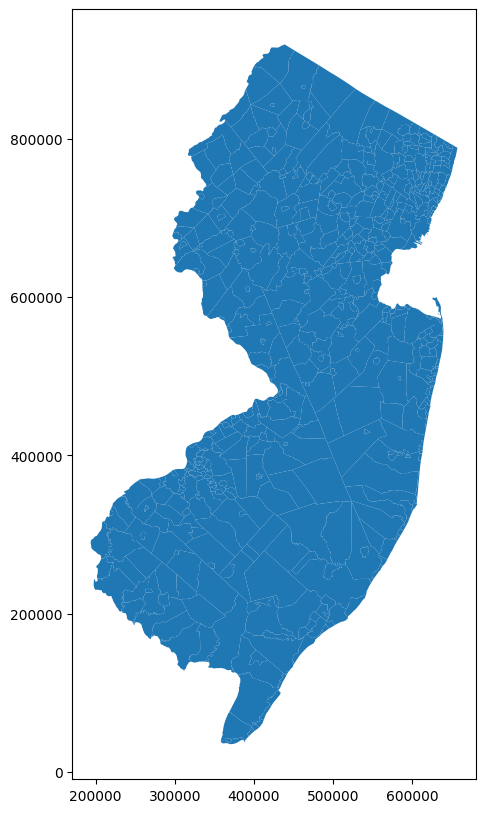

In [ ]:
njmuns = gdf
njmuns.plot(figsize=(10, 10))

In [ ]:
print("Shape:", njmuns.shape)

print("CRS:", njmuns.crs)

print("Columns:", list(njmuns.columns))

Shape: (564, 23)
CRS: EPSG:3424
Columns: ['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS', 'SSN', 'MUN_CODE', 'CENSUS2020', 'ACRES', 'SQ_MILES', 'POP2020', 'POP2010', 'POP2000', 'POP1990', 'POP1980', 'POPDEN2020', 'POPDEN2010', 'POPDEN2000', 'POPDEN1990', 'POPDEN1980', 'geometry']


In [ ]:
display(njmuns[["SSN", "NAME", "MUN_LABEL", "MUN_CODE", "MUN_TYPE", "COUNTY"]].head(20))

,SSN,NAME,MUN_LABEL,MUN_CODE,MUN_TYPE,COUNTY
0,0503,Cape May Point Borough,Cape May Point Borough,0503,Borough,CAPE MAY
1,0512,West Cape May Borough,West Cape May Borough,0512,Borough,CAPE MAY
2,0502,Cape May,Cape May City,0502,City,CAPE MAY
3,0515,Wildwood Crest Borough,Wildwood Crest Borough,0515,Borough,CAPE MAY
4,0513,West Wildwood Borough,West Wildwood Borough,0513,Borough,CAPE MAY
5,0507,North Wildwood,North Wildwood City,0507,City,CAPE MAY
6,0505,Lower Township,Lower Township,0505,Township,CAPE MAY
7,0510,Stone Harbor Borough,Stone Harbor Borough,0510,Borough,CAPE MAY
8,0501,Avalon Borough,Avalon Borough,0501,Borough,CAPE MAY
9,0509,Sea Isle City,Sea Isle City,0509,City,CAPE MAY


In [ ]:
# Create centroids in original projected CRS

njmuns["centroid_geom"] = njmuns.geometry.centroid

# Convert centroids to latitude/longitude

centroids = gpd.GeoDataFrame(

    njmuns[["SSN", "NAME", "COUNTY", "MUN_LABEL", "MUN_TYPE"]].copy(),

    geometry=njmuns["centroid_geom"],

    crs=njmuns.crs

)

centroids_latlon = centroids.to_crs(epsg=4326)
centroids_latlon["longitude"] = centroids_latlon.geometry.x
centroids_latlon["latitude"] = centroids_latlon.geometry.y

In [ ]:
# Create clean Dataset 2

dataset2 = centroids_latlon.rename(columns={
    "SSN": "muni_id",
    "NAME": "muni_name",
    "COUNTY": "county",
    "MUN_LABEL": "muni_label",
    "MUN_TYPE": "muni_type"
})
dataset2 = dataset2[[
    "muni_id",
    "muni_name",
    "county",
    "muni_label",
    "muni_type",
    "latitude",
    "longitude"
]].copy()

In [ ]:
dataset2.head()

,muni_id,muni_name,county,muni_label,muni_type,latitude,longitude
0,0503,Cape May Point Borough,CAPE MAY,Cape May Point Borough,Borough,38.937327,-74.965196
1,0512,West Cape May Borough,CAPE MAY,West Cape May Borough,Borough,38.942268,-74.937793
2,0502,Cape May,CAPE MAY,Cape May City,City,38.940731,-74.903202
3,0515,Wildwood Crest Borough,CAPE MAY,Wildwood Crest Borough,Borough,38.971699,-74.837587
4,0513,West Wildwood Borough,CAPE MAY,West Wildwood Borough,Borough,39.000608,-74.823547


In [ ]:
# Ensure municipality ID is 4-character string

dataset2["muni_id"] = dataset2["muni_id"].astype(str).str.zfill(4)

# Final checks

print("Dataset 2 shape:", dataset2.shape)

print("Municipality ID length check:")

print(dataset2["muni_id"].str.len().value_counts())

display(dataset2.head(20))

Dataset 2 shape: (564, 7)
Municipality ID length check:
muni_id
4    564
Name: count, dtype: int64


,muni_id,muni_name,county,muni_label,muni_type,latitude,longitude
0,0503,Cape May Point Borough,CAPE MAY,Cape May Point Borough,Borough,38.937327,-74.965196
1,0512,West Cape May Borough,CAPE MAY,West Cape May Borough,Borough,38.942268,-74.937793
2,0502,Cape May,CAPE MAY,Cape May City,City,38.940731,-74.903202
3,0515,Wildwood Crest Borough,CAPE MAY,Wildwood Crest Borough,Borough,38.971699,-74.837587
4,0513,West Wildwood Borough,CAPE MAY,West Wildwood Borough,Borough,39.000608,-74.823547
5,0507,North Wildwood,CAPE MAY,North Wildwood City,City,39.004642,-74.798522
6,0505,Lower Township,CAPE MAY,Lower Township,Township,38.981987,-74.908559
7,0510,Stone Harbor Borough,CAPE MAY,Stone Harbor Borough,Borough,39.038551,-74.773104
8,0501,Avalon Borough,CAPE MAY,Avalon Borough,Borough,39.090213,-74.736136
9,0509,Sea Isle City,CAPE MAY,Sea Isle City,City,39.151754,-74.698241


/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets


In [ ]:
from pathlib import Path

# Main project folder where your shapefile is stored
project_path = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424")

# Create output folder inside the project folder
output_path = project_path / "created_datasets"
output_path.mkdir(parents=True, exist_ok=True)

print(output_path)

/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/created_datasets


In [ ]:
csv_file = output_path / "dataset2_municipality_spatial_reference.csv"

dataset2.to_csv(csv_file, index=False)

print("Saved CSV to:")
print(csv_file)
print("File exists:", csv_file.exists())

Saved CSV to:
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/dataset2_municipality_spatial_reference.csv
File exists: True


In [ ]:
for item in output_path.iterdir():
    print(item.name)

dataset2_municipality_spatial_reference.csv


In [ ]:
dta_file = output_path / "dataset2_municipality_spatial_reference.dta"

dataset2.to_stata(
    dta_file,
    write_index=False,
    version=118
)

print("Saved Stata file to:")
print(dta_file)
print("File exists:", dta_file.exists())

Saved Stata file to:
/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/dataset2_municipality_spatial_reference.dta
File exists: True


In [ ]:
for item in output_path.iterdir():
    print(item.name)

dataset2_municipality_spatial_reference.csv
dataset2_municipality_spatial_reference.dta


In [ ]:
from pathlib import Path

# Make sure output_path is already defined
# If not, uncomment and edit this line:
# output_path = Path("/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets")

old_csv = output_path / "dataset2_municipality_spatial_reference.csv"
old_dta = output_path / "dataset2_municipality_spatial_reference.dta"

new_csv = output_path / "mun_geo.csv"
new_dta = output_path / "mun_geo.dta"

# Rename CSV
if old_csv.exists():
    old_csv.rename(new_csv)
    print("CSV renamed to:", new_csv.name)
else:
    print("Old CSV not found:", old_csv)

# Rename DTA
if old_dta.exists():
    old_dta.rename(new_dta)
    print("DTA renamed to:", new_dta.name)
else:
    print("Old DTA not found:", old_dta)

# Confirm folder contents
print("\nFiles now in output folder:")
for item in output_path.iterdir():
    print(item.name)

PosixPath('/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_geo.csv')

CSV renamed to: mun_geo.csv


PosixPath('/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/NJ_Municipal_Boundaries_3424/created_datasets/mun_geo.dta')

DTA renamed to: mun_geo.dta

Files now in output folder:
mun_geo.csv
mun_geo.dta


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Use your existing output_path
mun_geo = pd.read_csv(output_path / "mun_geo.csv", dtype={"muni_id": str})

mun_geo.head()

,muni_id,muni_name,county,muni_label,muni_type,latitude,longitude
0,0503,Cape May Point Borough,CAPE MAY,Cape May Point Borough,Borough,38.937327,-74.965196
1,0512,West Cape May Borough,CAPE MAY,West Cape May Borough,Borough,38.942268,-74.937793
2,0502,Cape May,CAPE MAY,Cape May City,City,38.940731,-74.903202
3,0515,Wildwood Crest Borough,CAPE MAY,Wildwood Crest Borough,Borough,38.971699,-74.837587
4,0513,West Wildwood Borough,CAPE MAY,West Wildwood Borough,Borough,39.000608,-74.823547


**Creating the municipality-pair dataset**

In [ ]:
# Keep only the variables needed for pair construction
a = mun_geo[["muni_id", "muni_name", "latitude", "longitude"]].copy()
b = mun_geo[["muni_id", "muni_name", "latitude", "longitude"]].copy()

# Rename variables for Municipality A
a = a.rename(columns={
    "muni_id": "muni_a_id",
    "muni_name": "muni_a_name",
    "latitude": "lat_a",
    "longitude": "lon_a"
})

# Rename variables for Municipality B
b = b.rename(columns={
    "muni_id": "muni_b_id",
    "muni_name": "muni_b_name",
    "latitude": "lat_b",
    "longitude": "lon_b"
})

# Cross join: every municipality A with every municipality B
a["key"] = 1
b["key"] = 1

mun_pairs = a.merge(b, on="key").drop(columns="key")

print(mun_pairs.shape)
mun_pairs.head()

(318096, 8)


,muni_a_id,muni_a_name,lat_a,lon_a,muni_b_id,muni_b_name,lat_b,lon_b
0,0503,Cape May Point Borough,38.937327,-74.965196,0503,Cape May Point Borough,38.937327,-74.965196
1,0503,Cape May Point Borough,38.937327,-74.965196,0512,West Cape May Borough,38.942268,-74.937793
2,0503,Cape May Point Borough,38.937327,-74.965196,0502,Cape May,38.940731,-74.903202
3,0503,Cape May Point Borough,38.937327,-74.965196,0515,Wildwood Crest Borough,38.971699,-74.837587
4,0503,Cape May Point Borough,38.937327,-74.965196,0513,West Wildwood Borough,39.000608,-74.823547


In [ ]:
## Calculating great-circle distance in miles

# Haversine distance formula, vectorized
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.7613  # Earth radius in miles

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    h = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(h))

mun_pairs["distance_miles"] = haversine_miles(
    mun_pairs["lat_a"],
    mun_pairs["lon_a"],
    mun_pairs["lat_b"],
    mun_pairs["lon_b"]
)

mun_pairs.head()

,muni_a_id,muni_a_name,lat_a,lon_a,muni_b_id,muni_b_name,lat_b,lon_b,distance_miles
0,0503,Cape May Point Borough,38.937327,-74.965196,0503,Cape May Point Borough,38.937327,-74.965196,0.000000
1,0503,Cape May Point Borough,38.937327,-74.965196,0512,West Cape May Borough,38.942268,-74.937793,1.511731
2,0503,Cape May Point Borough,38.937327,-74.965196,0502,Cape May,38.940731,-74.903202,3.340008
3,0503,Cape May Point Borough,38.937327,-74.965196,0515,Wildwood Crest Borough,38.971699,-74.837587,7.256135
4,0503,Cape May Point Borough,38.937327,-74.965196,0513,West Wildwood Borough,39.000608,-74.823547,8.776019


In [ ]:
## Creating Distance Indicators

mun_pairs["within_5_miles"] = (mun_pairs["distance_miles"] <= 5).astype(int)
mun_pairs["within_10_miles"] = (mun_pairs["distance_miles"] <= 10).astype(int)
mun_pairs["within_15_miles"] = (mun_pairs["distance_miles"] <= 15).astype(int)
mun_pairs["within_20_miles"] = (mun_pairs["distance_miles"] <= 20).astype(int)

mun_pairs.head()

,muni_a_id,muni_a_name,lat_a,lon_a,muni_b_id,muni_b_name,lat_b,lon_b,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,38.937327,-74.965196,0503,Cape May Point Borough,38.937327,-74.965196,0.000000,1,1,1,1
1,0503,Cape May Point Borough,38.937327,-74.965196,0512,West Cape May Borough,38.942268,-74.937793,1.511731,1,1,1,1
2,0503,Cape May Point Borough,38.937327,-74.965196,0502,Cape May,38.940731,-74.903202,3.340008,1,1,1,1
3,0503,Cape May Point Borough,38.937327,-74.965196,0515,Wildwood Crest Borough,38.971699,-74.837587,7.256135,0,1,1,1
4,0503,Cape May Point Borough,38.937327,-74.965196,0513,West Wildwood Borough,39.000608,-74.823547,8.776019,0,1,1,1


In [ ]:
## Keeping final variables for dataset 3

dataset3 = mun_pairs[[
    "muni_a_id",
    "muni_a_name",
    "muni_b_id",
    "muni_b_name",
    "distance_miles",
    "within_5_miles",
    "within_10_miles",
    "within_15_miles",
    "within_20_miles"
]].copy()

dataset3.head()

,muni_a_id,muni_a_name,muni_b_id,muni_b_name,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,0503,Cape May Point Borough,0.000000,1,1,1,1
1,0503,Cape May Point Borough,0512,West Cape May Borough,1.511731,1,1,1,1
2,0503,Cape May Point Borough,0502,Cape May,3.340008,1,1,1,1
3,0503,Cape May Point Borough,0515,Wildwood Crest Borough,7.256135,0,1,1,1
4,0503,Cape May Point Borough,0513,West Wildwood Borough,8.776019,0,1,1,1


In [ ]:
# Keep only municipality pairs within 20 miles
dataset3_20mi = dataset3[dataset3["distance_miles"] <= 20].copy()

print("Full pair dataset:", dataset3.shape)
print("Within-20-mile dataset:", dataset3_20mi.shape)

dataset3_20mi.head()

Full pair dataset: (318096, 9)
Within-20-mile dataset: (47966, 9)


,muni_a_id,muni_a_name,muni_b_id,muni_b_name,distance_miles,within_5_miles,within_10_miles,within_15_miles,within_20_miles
0,0503,Cape May Point Borough,0503,Cape May Point Borough,0.000000,1,1,1,1
1,0503,Cape May Point Borough,0512,West Cape May Borough,1.511731,1,1,1,1
2,0503,Cape May Point Borough,0502,Cape May,3.340008,1,1,1,1
3,0503,Cape May Point Borough,0515,Wildwood Crest Borough,7.256135,0,1,1,1
4,0503,Cape May Point Borough,0513,West Wildwood Borough,8.776019,0,1,1,1


In [ ]:
## Exporting Dataset3 as both the full pair dataset, and the within-20-mile dataset

# Export full pair dataset
dataset3.to_csv(output_path / "mun_pairs_full.csv", index=False)

dataset3.to_stata(
    output_path / "mun_pairs_full.dta",
    write_index=False,
    version=118
)

# Export within-20-mile working dataset
dataset3_20mi.to_csv(output_path / "mun_pairs_20mi.csv", index=False)

dataset3_20mi.to_stata(
    output_path / "mun_pairs_20mi.dta",
    write_index=False,
    version=118
)

print("Both full and within-20-mile pair datasets exported.")

Both full and within-20-mile pair datasets exported.


**Importing the Analytical Dataset**

In [ ]:
analytical = pd.read_stata(
    "/content/drive/MyDrive/2026_Dr. Hayes_SummerProjects/CannabisGISproject/can_modified.dta"
)

In [ ]:
# Making sure municipality code is in 4 digits
analytical["muni_id"] = analytical["muni_id"].astype(str).str.zfill(4)

In [ ]:
## Checking if the municipal ids in the analytical and muni_geo dataset merges

mun_geo = pd.read_csv(output_path / "mun_geo.csv", dtype={"muni_id": str})

analytical_ids = analytical[["muni_id"]].drop_duplicates()
geo_ids = mun_geo[["muni_id", "muni_name", "county"]].drop_duplicates()

id_check = analytical_ids.merge(
    geo_ids,
    on="muni_id",
    how="outer",
    indicator=True
)

id_check["_merge"].value_counts()

,count
_merge,
both,564
left_only,1
right_only,0


In [ ]:
id_check[id_check["_merge"] == "left_only"]

,muni_id,muni_name,county,_merge
161,0429,NaN,NaN,left_only


In [ ]:
name_check = analytical[["muni_id", "muni_name"]].drop_duplicates().merge(
    mun_geo[["muni_id", "muni_name"]].rename(columns={"muni_name": "gis_muni_name"}),
    on="muni_id",
    how="left"
)

name_check["name_match"] = (
    name_check["muni_name"].str.upper().str.strip()
    ==
    name_check["gis_muni_name"].str.upper().str.strip()
)

name_check["name_match"].value_counts()

,count
name_match,
False,553
True,13


In [ ]:
name_check[name_check["name_match"] == False]

,muni_id,muni_name,gis_muni_name,name_match
0,0101,Absecon City,Absecon,False
2,0103,Brigantine City,Brigantine,False
3,0104,Buena Boro,Buena Borough,False
4,0105,Buena Vista Twp,Buena Vista Township,False
7,0108,Egg Harbor Twp,Egg Harbor Township,False
...,...,...,...,...
561,2119,Phillipsburg Town,Phillipsburg,False
562,2120,Pohatcong Twp,Pohatcong Township,False
563,2121,Washington Boro,Washington Borough,False
564,2122,Washington Twp,Washington Township,False


In [ ]:
del name_check
"name_check" in globals()

False

In [ ]:
# Removing the only municipal that did not merge "0429"

analytical = analytical[analytical["muni_id"] != "0429"].copy()
analytical["muni_id"].nunique()

564

In [ ]:
analytical_ids = analytical[["muni_id"]].drop_duplicates()
geo_ids = mun_geo[["muni_id", "muni_name", "county"]].drop_duplicates()

id_check = analytical_ids.merge(
    geo_ids,
    on="muni_id",
    how="outer",
    indicator=True
)

id_check["_merge"].value_counts()

,count
_merge,
both,564
left_only,0
right_only,0


Merging mun_geo with the analytical data

In [ ]:
analytical_geo = analytical.merge(
    mun_geo[["muni_id", "muni_name", "county", "latitude", "longitude"]],
    on="muni_id",
    how="left",
    suffixes=("", "_gis")
)

print("Missing latitude after merge:", analytical_geo["latitude"].isna().sum())

Missing latitude after merge: 0


In [ ]:
analytical_geo.to_csv(output_path / "analytical_with_geo.csv", index=False)

analytical_geo.to_stata(
    output_path / "analytical_with_geo.dta",
    write_index=False,
    version=118
)

In [ ]:
analytical_geo.head()

,muni_id,muni_name,year,can_rev,can_rev_pcap,can_active,opted_in,eff_tax_rate,mri_score,dem_vote,eqprop_val,state_rev,pop,age65_over,muni_name_gis,county,latitude,longitude
0,0101,Absecon City,2016.0,0.0,0.0,0.0,1.0,2.918781,-3.600225,50.310001,747805564.0,757801.940,8438.0,20.4,Absecon,ATLANTIC,39.42274,-74.49432
1,0101,Absecon City,2017.0,0.0,0.0,0.0,1.0,3.096136,-3.600225,50.310001,727840911.0,757801.945,8370.0,21.2,Absecon,ATLANTIC,39.42274,-74.49432
2,0101,Absecon City,2018.0,0.0,0.0,0.0,1.0,3.188293,-3.600225,50.310001,749575777.0,757801.950,8289.0,22.3,Absecon,ATLANTIC,39.42274,-74.49432
3,0101,Absecon City,2019.0,0.0,0.0,0.0,1.0,3.076000,-3.036593,50.310001,743893642.0,757801.940,8362.0,22.8,Absecon,ATLANTIC,39.42274,-74.49432
4,0101,Absecon City,2020.0,0.0,0.0,0.0,1.0,3.137155,-3.036593,50.310001,717707095.0,757801.860,8471.0,22.0,Absecon,ATLANTIC,39.42274,-74.49432


## **CREATING THE HYPOTHETICAL RETAILER DATASET**

### Cannabis Spatial Variable Prototype

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Main project folder
project_path = Path(
    "/content/drive/MyDrive/"
    "2026_Dr. Hayes_SummerProjects/"
    "CannabisGISproject"
)

# Folder containing the previously created datasets
# Change this path only if your files are stored elsewhere.
data_path = (
    project_path
    / "NJ_Municipal_Boundaries_3424"
    / "created_datasets"
)

# Folder for prototype outputs
prototype_path = project_path / "prototype_spatial_variables"
prototype_path.mkdir(parents=True, exist_ok=True)

print("Input folder exists:", data_path.exists())
print("Prototype output folder:", prototype_path)